In [92]:
!rm -f patsy.py statsmodels.py seaborn.py

In [93]:
import warnings
warnings.filterwarnings('ignore')
!pip install underthesea
# Underthesea - A Vietnamese NLP toolkit 
from underthesea import word_tokenize
from underthesea import text_normalize

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import wordcloud
import regex as re
import string
import random
import nltk
from datasets import load_dataset
from inspect import signature

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, concatenate
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# scikit-learn
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MaxAbsScaler

In [94]:
import pandas as pd
import matplotlib.pyplot as plt

# Ép hệ thống nạp patsy và statsmodels trước để tránh kẹt vòng lặp
import patsy
import statsmodels.api as sm 

# Nạp seaborn sau cùng
import seaborn as sns
%matplotlib inline

print("Import thành công!")

Import thành công!


In [95]:
# Gọi hàm ra từ thư viện datasets
from datasets import load_dataset
 

In [96]:
from datasets import load_dataset, disable_progress_bar

# Tắt thanh tiến trình để tránh lỗi Javascript của Kaggle
disable_progress_bar()

# Tải dữ liệu như bình thường
dataset = load_dataset("uit-nlp/vietnamese_students_feedback") 

train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

# Ghép các DataFrames (Concatenate)
import pandas as pd
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Trộn đều dữ liệu (Shuffle)
df = df.sample(frac=1).reset_index(drop=True)
df.rename(columns={'sentence': 'content', 'sentiment': 'label'}, inplace=True)

print("Đã tải và xử lý dữ liệu thành công!")

Đã tải và xử lý dữ liệu thành công!


In [97]:
# Lưu vào thư mục làm việc của Kaggle
df.to_csv('/kaggle/working/vietnamese_students_feedback_processed.csv', index=False, encoding='utf-8-sig')

print("Đã lưu file CSV thành công vào thư mục /kaggle/working!")

Đã lưu file CSV thành công vào thư mục /kaggle/working!


In [98]:
print('Dataset columns, rows:', df.shape)
print('How many labels and their counts?:', df['label'].value_counts())
print('How many kind of topic and their counts?:', df['topic'].value_counts())

Dataset columns, rows: (16175, 3)
How many labels and their counts?: label
2    8038
0    7439
1     698
Name: count, dtype: int64
How many kind of topic and their counts?: topic
0    11607
1     3040
3      816
2      712
Name: count, dtype: int64


## Text Preprocessing

In [99]:
df = df.drop_duplicates("content") # drop duplicates
df = df.dropna() # drop null
print('How many label and their count left?:', df['label'].value_counts())

How many label and their count left?: label
2    8038
0    7438
1     698
Name: count, dtype: int64


In [100]:
!pip install underthesea

In [101]:
from underthesea import text_normalize, word_tokenize

In [102]:
import re, string 
emoji_pattern = re.compile("["
                u"\U0001F600-\U0001F64F"
                u"\U0001F300-\U0001F5FF" 
                u"\U0001F680-\U0001F6FF"  
                u"\U0001F1E0-\U0001F1FF"  
                u"\U00002702-\U000027B0"
                u"\U000024C2-\U0001F251"
                u"\U0001f926-\U0001f937"
                u'\U00010000-\U0010ffff'
                u"\u200d"
                u"\u2640-\u2642"
                u"\u2600-\u2B55"
                u"\u23cf"
                u"\u23e9"
                u"\u231a"
                u"\u3030"
                u"\ufe0f"
    "]+", flags=re.UNICODE) # Unicode emojis. 

def clean_text(text):
    text = text.lower() # lowercase text
    
    text = re.sub(emoji_pattern, " ", text) # remove emojis
    
    text = re.sub(r'([a-z]+?)\1+',r'\1', text) # reduce repeated character (e.g. 'aaabbb' -> 'ab')
    
    # Ensure space before and after any punctuation mark
    text = re.sub(r"(\w)\s*([" + string.punctuation + "])\s*(\w)", r"\1 \2 \3", text)
    text = re.sub(r"(\w)\s*([" + string.punctuation + "])", r"\1 \2", text)
    
    text = re.sub(f"([{string.punctuation}])([{string.punctuation}])+",r"\1", text) # reduce consecutive punctuation
    
    # Remove any leading or trailing spaces, or leading or trailing punctuation marks from the text
    text = text.strip()
    while text.endswith(tuple(string.punctuation+string.whitespace)):
        text = text[:-1]
    while text.startswith(tuple(string.punctuation+string.whitespace)):
        text = text[1:]
        
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuation
        
    text = re.sub(r"\s+", " ", text) # reduce multiple spaces
    
    text = text_normalize(text) # make sure punctunation is in the right letter (Vietnamese case)
    text = word_tokenize(text, format="text") # tokenize the cleaned text
    # text = unidecode(text) # remove accent marks from sentences (no significant difference when accent marks is removed or kept)
    
    '''
    Proper tokenization allows models or algorithms to understand the semantics of the text better. 
    For instance, `"đi chơi" (go play)` should be treated as one unit 
    instead of two separate words "đi" (go) and "chơi" (play) for proper semantic understanding.
    '''
    return text

In [103]:
df['corpus'] = df['content'].map(lambda text: clean_text(text))                                                     
# Final check
df.head(30)

,content,label,topic,corpus
0,thầy nên gửi slide trước ngày học trên giảng đ...,0,0,thầy nên gửi slide trước ngày học trên giảng_đ...
1,cám ơn thầy wzjwz296 .,1,0,cám ơn thầy wzjwz296
2,bài tập trên lớp .,1,1,bài_tập trên lớp
3,giáo viên nên làm nhiều bài tập mẫu cho sinh v...,0,0,giáo_viên nên làm nhiều bài_tập mẫu cho sinh_viên
4,hướng dẫn nhiệt tình .,2,0,hướng_dẫn nhiệt_tình
5,cách dạy hơi nhanh .,0,0,cách dạy hơi nhanh
6,"cô vui tính , dễ thương và dạy rất nhiệt tình .",2,0,cô vui_tính dễ_thương và dạy rất nhiệt_tình
7,"nhiều ví dụ minh hoạ , dễ hiểu .",2,0,nhiều ví_dụ minh_họa dễ hiểu
8,thầy nói tiếng anh còn hơi chậm và không lưu l...,0,0,thầy nói tiếng anh còn hơi chậm và không lưu_l...
9,ít hướng dẫn sinh viên trong giờ thực hành .,0,0,ít hướng_dẫn sinh_viên trong giờ thực_hành


## Exploratory Data Analysis

Number of words: 16001
Most common words: [('thầy dạy hay dễ hiểu', 4), ('giảng_viên nhiệt_tình tận_tâm', 3), ('giảng_viên tận_tâm nhiệt_tình', 3), ('thầy dạy nhiệt_tình tận_tâm', 3), ('nhiệt_tình vui_tính', 3), ('giảng_viên dạy nhiệt_tình dễ hiểu', 3), ('em cảm_ơn', 3), ('nhiệt_tình tâm_huyết', 3), ('khó tiếp_thu', 2), ('đến lớp đúng giờ', 2), ('cô dạy hay nhiệt_tình', 2), ('cô dạy nhiệt_tình dễ hiểu', 2), ('nhiệt_tình tận_tâm', 2), ('giảng_viên vui_vẻ nhiệt_tình', 2), ('vui_tính nhiệt_tình', 2)]


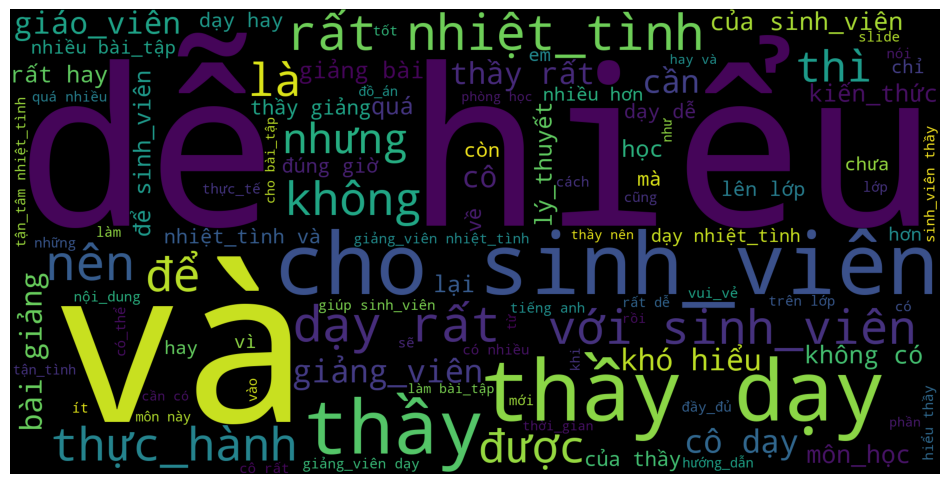

In [104]:
# Create bag-of-words
all_words = [token for token in df['corpus'].tolist() if token and token != '']

corpus=' '.join(all_words)
all_words = nltk.FreqDist(all_words)

# Print the total number of words and the 15 most common words
print('Number of words: {}'.format(len(all_words)))
print('Most common words: {}'.format(all_words.most_common(15)))

plt.figure(figsize=(12,8))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=2000,height=1000,mode="RGB").generate(corpus)
plt.axis("off")
plt.imshow(word_cloud)

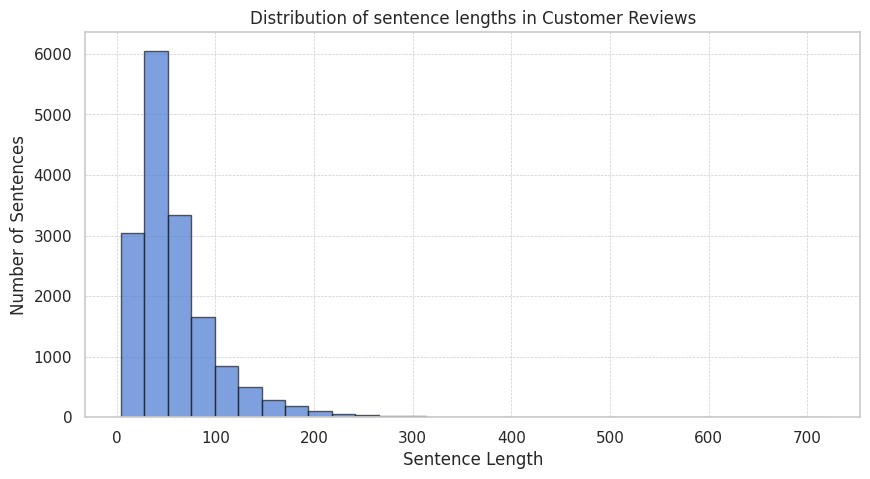

In [105]:
# Calculate the length of each sentence directly
lengths = df['content'].apply(len)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of sentence lengths in Customer Reviews')
plt.xlabel('Sentence Length')
plt.ylabel('Number of Sentences')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

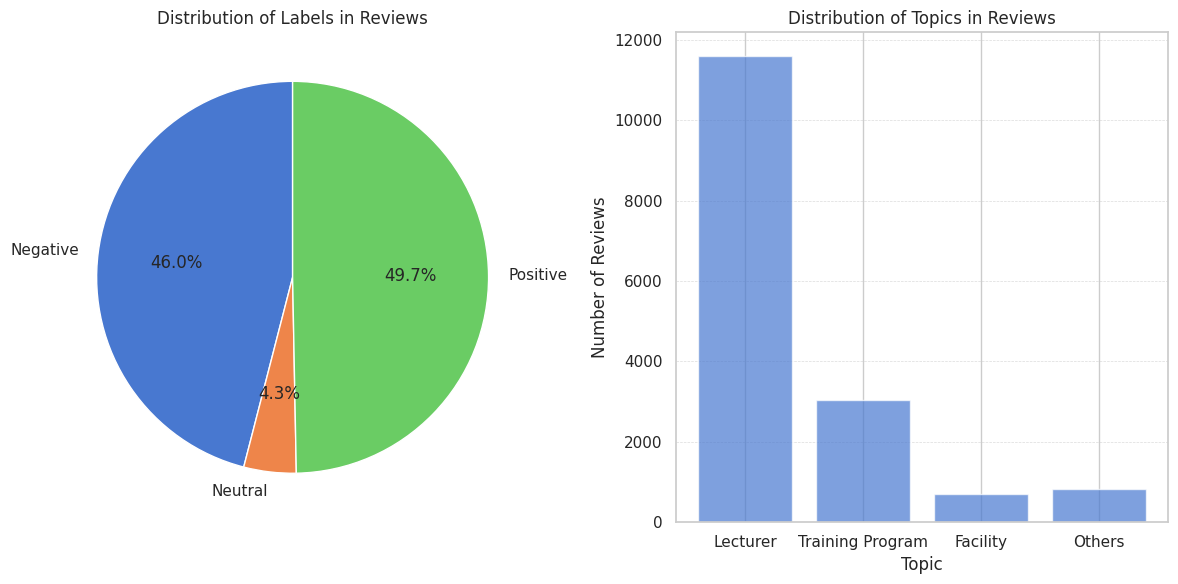

In [106]:
# Count the occurrences of each label and topic
label_counts = df['label'].value_counts().sort_index()
topic_counts = df['topic'].value_counts().sort_index()

# Set up the figure and axis
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for labels
labels = ['Negative', 'Neutral', 'Positive']  # updated labels
ax[0].pie(label_counts, labels=labels, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Distribution of Labels in Reviews')

# Bar chart for topics
topics = ['Lecturer', 'Training Program', 'Facility', 'Others']  # updated topics
ax[1].bar(topics, topic_counts, alpha=0.7)
ax[1].set_title('Distribution of Topics in Reviews')
ax[1].set_xlabel('Topic')
ax[1].set_ylabel('Number of Reviews')
ax[1].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Show the plots
plt.tight_layout()
plt.show()

In [107]:
# First, split the data into 80% training and 20% temporary testing.
train_sentences, test_sentences, train_labels, test_labels = train_test_split(
    df['corpus'], 
    df['label'], 
    test_size=0.1, 
    stratify=df['topic'],
    random_state=42
)

## Over-sampling

In [108]:
from sklearn.utils import resample

# Separate neutral comments
neutral_indices = np.where(train_labels == 1)[0]
oversample_size = len(train_labels[train_labels == 0]) - len(neutral_indices)

# Over-sample the neutral comments
oversampled_neutral_indices = resample(neutral_indices,
                                       replace=True,
                                       n_samples=oversample_size)

# Combine the original sentences and labels with the oversampled data
oversampled_neutral_sentences = np.array(train_sentences)[oversampled_neutral_indices]

train_sentences_oversampled = np.concatenate([train_sentences, oversampled_neutral_sentences], axis=0)
train_labels_oversampled = np.concatenate([train_labels, np.array([1] * oversample_size)], axis=0)


In [109]:
oversampled_neutral_sentences = np.array(train_sentences)[oversampled_neutral_indices]

train_sentences_oversampled = np.concatenate([train_sentences, oversampled_neutral_sentences], axis=0)
train_labels_oversampled = pd.Series(train_labels_oversampled)

In [110]:
# Count occurrences of each label in train_labels_oversampled
unique_labels, counts = np.unique(train_labels_oversampled, return_counts=True)

# Display the distribution
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count}")

Label 0: 6682
Label 1: 6682
Label 2: 7237


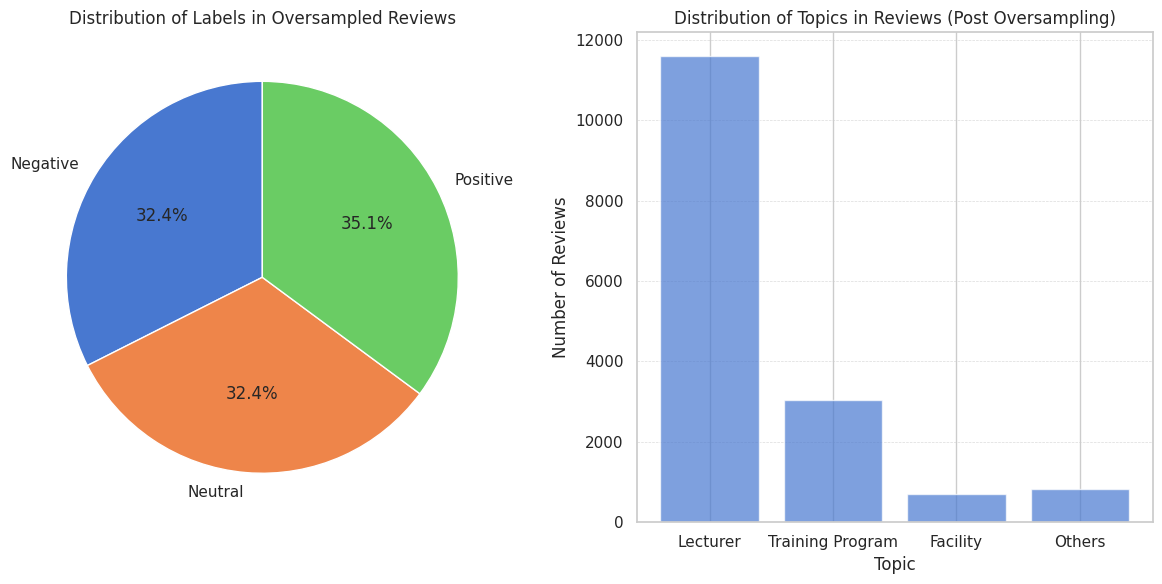

In [111]:
# First, you need to create a new DataFrame or series for your oversampled data
# For this example, let's assume your oversampled DataFrame is `df_oversampled`

# Update the label counts based on the oversampled data
label_counts_oversampled = pd.Series(train_labels_oversampled).value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for labels after over-sampling
labels = ['Negative', 'Neutral', 'Positive']  
ax[0].pie(label_counts_oversampled, labels=labels, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Distribution of Labels in Oversampled Reviews')

# Bar chart for topics (assuming they were oversampled too)
topics = ['Lecturer', 'Training Program', 'Facility', 'Others']
ax[1].bar(topics, topic_counts, alpha=0.7)
ax[1].set_title('Distribution of Topics in Reviews (Post Oversampling)')
ax[1].set_xlabel('Topic')
ax[1].set_ylabel('Number of Reviews')
ax[1].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

## Bag of Words

In [112]:

# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit the vectorizer on the training data only
vectorizer.fit(train_sentences)

CountVectorizer()

In [113]:
sample_sentences = df['corpus'].head(5).tolist() # select a sample of sentences
sample_transformed = vectorizer.transform(sample_sentences) # transform the sample sentences

sample_array = sample_transformed.toarray() # convert the transformed data

# Print results for each sentence in the sample
for idx, sentence in enumerate(sample_sentences):
    print(f"Sentence: {sentence}")
    print("Token : Count")
    for token, count in zip(vectorizer.get_feature_names_out(), sample_array[idx]):
        if count > 0:
            print(f"{token} : {count}")
    print("------\n")

Sentence: thầy nên gửi slide trước ngày học trên giảng_đường để sinh_viên tham_khảo trước chủ_động hơn khi học
Token : Count
chủ_động : 1
giảng_đường : 1
gửi : 1
hơn : 1
học : 2
khi : 1
ngày : 1
nên : 1
sinh_viên : 1
slide : 1
tham_khảo : 1
thầy : 1
trên : 1
trước : 2
để : 1
------

Sentence: cám ơn thầy wzjwz296
Token : Count
cám : 1
thầy : 1
wzjwz296 : 1
ơn : 1
------

Sentence: bài_tập trên lớp
Token : Count
bài_tập : 1
lớp : 1
trên : 1
------

Sentence: giáo_viên nên làm nhiều bài_tập mẫu cho sinh_viên
Token : Count
bài_tập : 1
cho : 1
giáo_viên : 1
làm : 1
mẫu : 1
nhiều : 1
nên : 1
sinh_viên : 1
------

Sentence: hướng_dẫn nhiệt_tình
Token : Count
hướng_dẫn : 1
nhiệt_tình : 1
------



In [114]:
# Convert the entire oversampled sentences into the Bag-of-Words representation
X_oversampled_bow = vectorizer.transform(train_sentences_oversampled)
y_oversampled_bow = train_labels_oversampled

+ Text vectorization converts raw text into integer sequences, without capturing semantic meaning. 

+ Embeddings, on the other hand, transform these integers into dense vectors that capture semantic relationships between words. 

+ `Using separate embeddings for different models allows each model to learn task-specific semantic representations`. This can improve model performance as the embedding space becomes tailored to each task's nuances.

## Text Vectorization

In [115]:
MAX_VOCAB_LENGTH = 20000

sequence_lengths = [len(sentence.split()) for sentence in train_sentences] # Calculate the length of each sentence in the training data
MAX_LENGTH = int(np.percentile(sequence_lengths, 95)) # Set MAX_LENGTH as the 95th percentile of the sequence lengths

In [116]:
text_vectorizer = TextVectorization(max_tokens=MAX_VOCAB_LENGTH, # Maximum size of the vocabulary for this layer
                                    standardize="lower_and_strip_punctuation", # Text will be lowercased and all punctuation removed
                                    split="whitespace", # Split on whitespace
                                    ngrams=None, 
                                    output_mode="int", # Outputs integer indices, one integer index per split string token
                                    output_sequence_length=MAX_LENGTH) # the output will have its time dimension padded or truncated to exactly output_sequence_length values

text_vectorizer.adapt(train_sentences) # Computes a vocabulary of string terms from tokens in a dataset.

In [117]:
words_in_vocab = text_vectorizer.get_vocabulary()
top_5_words = words_in_vocab[:5] # ([UNK] token is unknown words)
bottom_5_words = words_in_vocab[-5:] 
print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"Top 5 most common words: {top_5_words}")
print(f"Bottom 5 least common words: {bottom_5_words}")

Number of words in vocab: 4555
Top 5 most common words: ['', '[UNK]', 'thầy', 'sinhviên', 'dạy']
Bottom 5 least common words: ['2007', '2000', '1983', '140', '14']


## Embedding

In [118]:
def create_embedding_layer(input_dim=MAX_VOCAB_LENGTH, output_dim=128, embeddings_initializer="uniform", input_length=MAX_LENGTH, name=None):
    """
    Create an Embedding layer for use in a deep learning model.

    Parameters:
    - input_dim (int): Size of the input vocabulary.
    - output_dim (int, optional): Dimension of the dense embedding. Defaults to 128.
    - embeddings_initializer (str or keras.initializers, optional): Initializer for the embeddings matrix. Defaults to "uniform".
    - input_length (int, optional): Length of input sequences, when it is constant.
    - name (str, optional): Name of the layer. Defaults to None.

    Returns:
    - TensorFlow/Keras Embedding layer.
    """
    return layers.Embedding(
        input_dim=input_dim,
        output_dim=output_dim,
        embeddings_initializer=embeddings_initializer,
        input_length=input_length,
        name=name
    )

## Machine Learning Models

#### Optimized Functions for ML Training

In [119]:
def create_ml_model(model_type, **kwargs):
    '''
    Create Machine Learning model
    '''
    models = {
        'naive_bayes': MultinomialNB,
        'svm': LinearSVC,
        'random_forest': RandomForestClassifier,
        'logistic_regression': LogisticRegression,
        'ml_ensemble': lambda: create_ml_stacking_classifier(**kwargs)
    }
    
    # Retrieve the model class based on the model_type argument
    model = models.get(model_type.lower())
    
    # Check if the model type exists
    if model:
        return model(**kwargs)
    else:
        supported_models = ", ".join(models.keys())
        print(f"Error: Model type '{model_type}' is not supported.\n"
              f"Supported models are: {supported_models}.\n"
              f"Please add your perferred model to create_model function.")
        return None

In [120]:
def kfold_evaluation(model, X, y, kfold):
    '''
    1. Train ML model on KFold
    
    2. Return metrics for each KFold and all KFolds
    '''
    fold_results = [] # average validation data results on all Kfolds
    fold_result_each_kfold = [] # training and validation results on each Kfold

    for train_index, val_index in skf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict on both sets
        train_predictions = model.predict(X_train)
        val_predictions = model.predict(X_val)
        
        # Calculate metrics for both sets
        train_metrics = calculate_results(y_train, train_predictions)
        val_metrics = calculate_results(y_val, val_predictions)

        fold_result = {
            'fold': len(fold_results) + 1,
            'train_metrics': train_metrics,
            'validation_metrics': val_metrics
        }

        fold_results.append(val_metrics)
        fold_result_each_kfold.append(fold_result)

    # Compute the average metrics over all folds
    model_results = {
        "accuracy": np.mean([result["accuracy"] for result in fold_results]),
        "precision": np.mean([result["precision"] for result in fold_results]),
        "recall": np.mean([result["recall"] for result in fold_results]),
        "f1": np.mean([result["f1"] for result in fold_results])
    }

    # Retrain the model on the entire dataset
    model.fit(X, y)

    return model, fold_result_each_kfold, model_results

In [121]:
def calculate_results(y_true, y_pred):
    '''
    Calculate accuracy, precision, recall, f1 score for a model
    '''
    model_accuracy = accuracy_score(y_true, y_pred) * 100  # Scale to 1-100
    model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    
    model_results = {
        "accuracy": model_accuracy,
        "precision": model_precision,
        "recall": model_recall,
        "f1": model_f1
    }
    
    return model_results

In [122]:
def compare_baseline_to_new_results(baseline_results, new_model_results, baseline_name='Baseline', new_model_name='New Model'):
    '''
    Compare baseline and new model results on metrics and plot the results using a line graph.
    '''
    metrics = list(baseline_results.keys())
    baseline_scores = [baseline_results[metric] * 100 if metric != 'accuracy' else baseline_results[metric] for metric in metrics]
    new_model_scores = [new_model_results[metric] * 100 if metric != 'accuracy' else new_model_results[metric] for metric in metrics]

    # Textual comparison
    # for key, value in baseline_results.items():
        # print(f"{baseline_name} {key}: {value:.2f}, {new_model_name} {key}: {new_model_results[key]:.2f}, Difference: {new_model_results[key]-value:.2f}")

    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    colors = ["#3498db", "#e74c3c"]  # Blue for baseline, Red for new model

    # Plotting
    x = np.arange(len(metrics))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, baseline_scores, label=baseline_name, marker='o', markersize=6, linewidth=2, color=colors[0])
    ax.plot(x, new_model_scores, label=new_model_name, marker='s', markersize=6, linewidth=2, color=colors[1])
    
    # Adjust y-axis range
    max_score = max(max(baseline_scores), max(new_model_scores))
    min_score = min(min(baseline_scores), min(new_model_scores))
    ax.set_ylim([min_score - 1, max_score + 1])  # Add padding to the top and bottom
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Scores (%)')
    ax.set_title(f'Performance Comparison: {baseline_name} vs {new_model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    # Attach a text label at each marker, displaying its height with increased vertical offset
    label_offset = 0.25  # Increased vertical offset for the labels
    for i in range(len(metrics)):
        ax.text(x[i], baseline_scores[i] + label_offset, f'{baseline_scores[i]:.2f}%', ha='center', va='bottom')
        ax.text(x[i], new_model_scores[i] + label_offset, f'{new_model_scores[i]:.2f}%', ha='center', va='bottom')

    fig.tight_layout()
    plt.show()

In [123]:
def format_metrics_compact(metrics):
    '''
    Helper function to format metrics compactly
    '''
    return ", ".join([f"{key.capitalize()}: {value:.2f}" for key, value in metrics.items()])

def display_all_folds_results(model_name, model_results):
    '''
    Print average metrics of validation data on all KFolds
    '''
    print(f"Average {model_name} Performance Metrics Across All Folds (on validation data):")
    print(f"- Accuracy: {model_results['accuracy']:.2f}%")
    print(f"- Precision: {model_results['precision']:.4f}")
    print(f"- Recall: {model_results['recall']:.4f}")
    print(f"- F1 Score: {model_results['f1']:.4f}")

In [124]:
def display_each_fold_result(model_name, fold_results):
    '''
    Print metrics of training and validation data on each KFold and plot the accuracy graph using Seaborn.
    '''
    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    colors = ["#3498db", "#e74c3c"]  # Blue for Training, Red for Validation

    # Header
    print(f"{model_name} Performance Metrics Across Each Fold (on training and validation data):")
    print()
    print(f"{'Fold':<5} | {'Training Metrics':<70} | {'Validation Metrics':<70}")
    print("-" * 150)

    # Prepare data for plotting
    train_accuracies = []
    val_accuracies = []
    folds = []

    # Display results for each fold and collect data for graph
    for result in fold_results:
        train_metrics_formatted = format_metrics_compact(result['train_metrics'])
        val_metrics_formatted = format_metrics_compact(result['validation_metrics'])
        print(f"{result['fold']:<5} | {train_metrics_formatted:<70} | {val_metrics_formatted:<70}")

        # Append data for graph
        folds.append(result['fold'])
        train_accuracies.append(result['train_metrics']['accuracy'])
        val_accuracies.append(result['validation_metrics']['accuracy'])

    # Plotting the accuracies using Seaborn
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(x=folds, y=train_accuracies, label='Training Accuracy', marker='o', color=colors[0])
    sns.lineplot(x=folds, y=val_accuracies, label='Validation Accuracy', marker='o', color=colors[1])
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Adding percentages on markers
    label_offset = 0.25  # Increased vertical offset for the labels
    for i, (tr_acc, val_acc) in enumerate(zip(train_accuracies, val_accuracies)):
        ax.text(folds[i], tr_acc + label_offset, f"{tr_acc:.2f}%", ha='center', va='bottom')
        ax.text(folds[i], val_acc + label_offset, f"{val_acc:.2f}%", ha='center', va='bottom')

    plt.title(f"{model_name} model: Training vs Validation Accuracy per Fold")
    plt.xlabel('Fold')
    plt.ylabel('Accuracy (%)')
    plt.xticks(folds)
    plt.legend()
    ax.margins(y=0.2)  # Add 10% padding to the top and bottom
    fig.tight_layout()
    plt.show()

In [125]:
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True)

### Model 0: Logistic Regression (Base Model)

In [126]:
lr_model = create_ml_model('logistic_regression', max_iter=5000, solver='saga', multi_class='multinomial') # Set for multi-class classification

In [127]:
lr_model, lr_each_fold_results, lr_results = kfold_evaluation(lr_model, X_oversampled_bow, y_oversampled_bow, skf)

In [128]:
display_all_folds_results("Logistic Regression", lr_results)

Average Logistic Regression Performance Metrics Across All Folds (on validation data):
- Accuracy: 89.70%
- Precision: 0.9001
- Recall: 0.8970
- F1 Score: 0.8969


Logistic Regression Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 93.74, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 89.64, Precision: 0.90, Recall: 0.90, F1: 0.90              
2     | Accuracy: 93.85, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 89.66, Precision: 0.90, Recall: 0.90, F1: 0.90              
3     | Accuracy: 93.73, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 89.73, Precision: 0.90, Recall: 0.90, F1: 0.90              
4     | Accuracy: 93.76, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 89.83, Precision: 0.90, Recall: 0.90, F1: 0.90           

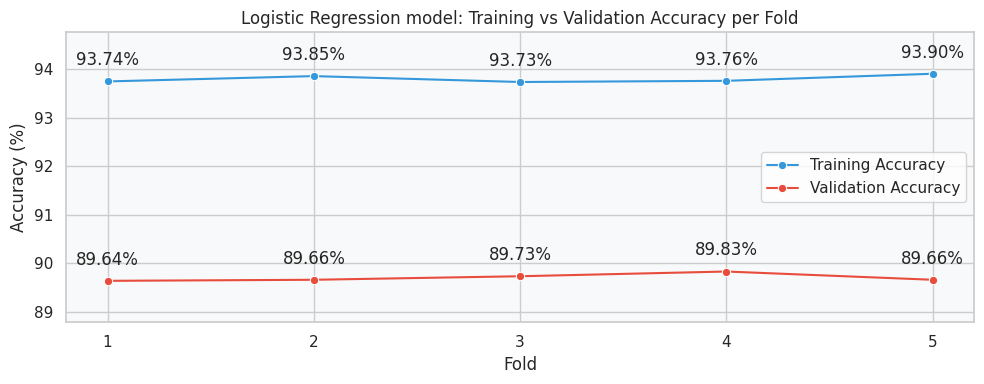

In [129]:
display_each_fold_result("Logistic Regression",lr_each_fold_results)

### Model 1: Support Vector Machines (SVM)

In [130]:
svm_model= create_ml_model('svm', max_iter=5000)

In [131]:
svm_model, svm_each_fold_results, svm_results = kfold_evaluation(svm_model, X_oversampled_bow, y_oversampled_bow, skf)

In [132]:
display_all_folds_results("SVM", svm_results)

Average SVM Performance Metrics Across All Folds (on validation data):
- Accuracy: 90.58%
- Precision: 0.9080
- Recall: 0.9058
- F1 Score: 0.9055


SVM Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 95.70, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 90.58, Precision: 0.91, Recall: 0.91, F1: 0.91              
2     | Accuracy: 95.73, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 90.05, Precision: 0.90, Recall: 0.90, F1: 0.90              
3     | Accuracy: 95.64, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 90.51, Precision: 0.91, Recall: 0.91, F1: 0.90              
4     | Accuracy: 95.79, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 90.41, Precision: 0.91, Recall: 0.90, F1: 0.90              
5     | Accu

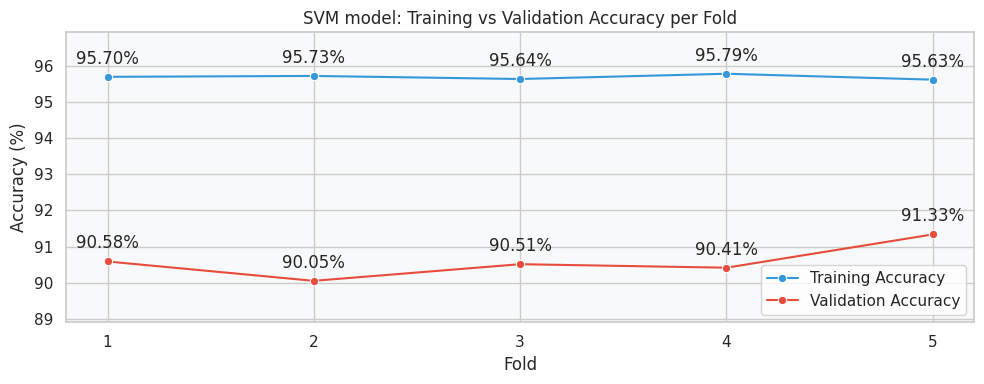

In [133]:
display_each_fold_result("SVM",svm_each_fold_results)

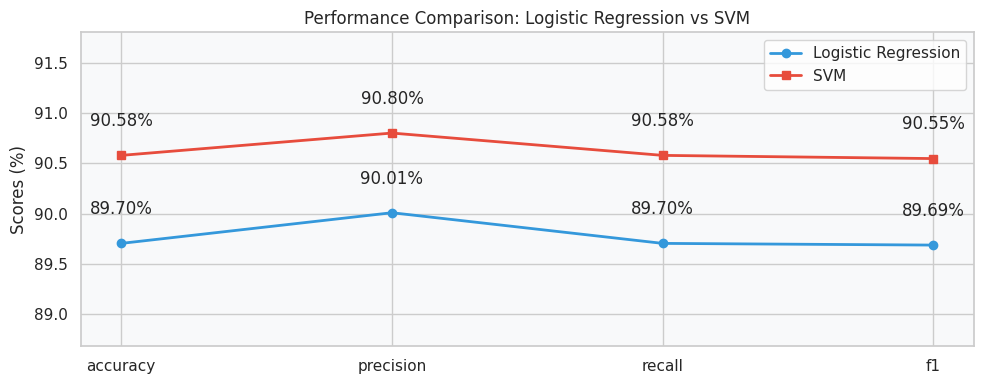

In [134]:
# Compare Model 1: Support Vector Machines model with Model 0: Logistic Regression
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=svm_results,
                                baseline_name='Logistic Regression', new_model_name='SVM')

### Model 2: Random Forest

In [135]:
rf_model= create_ml_model('random_forest', n_estimators=100)

In [136]:
rf_model, rf_each_fold_results, rf_results = kfold_evaluation(rf_model, X_oversampled_bow, y_oversampled_bow, skf)

In [137]:
display_all_folds_results("Random Forest", rf_results)

Average Random Forest Performance Metrics Across All Folds (on validation data):
- Accuracy: 93.67%
- Precision: 0.9370
- Recall: 0.9367
- F1 Score: 0.9362


Random Forest Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 99.99, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 93.47, Precision: 0.93, Recall: 0.93, F1: 0.93              
2     | Accuracy: 99.99, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 94.03, Precision: 0.94, Recall: 0.94, F1: 0.94              
3     | Accuracy: 99.99, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 93.23, Precision: 0.93, Recall: 0.93, F1: 0.93              
4     | Accuracy: 99.99, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 93.79, Precision: 0.94, Recall: 0.94, F1: 0.94              
5 

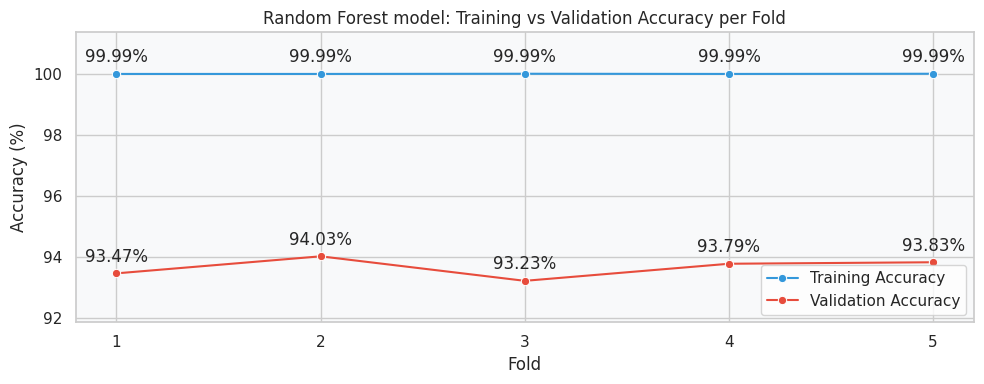

In [138]:
display_each_fold_result("Random Forest",rf_each_fold_results)

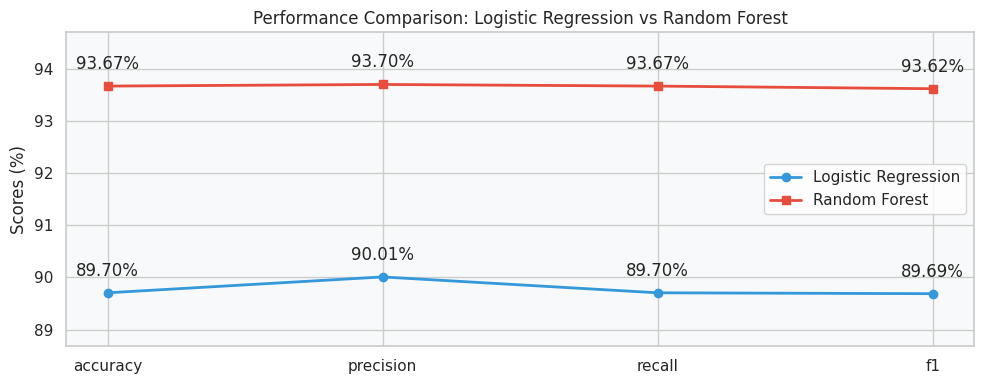

In [139]:
# Compare Model 2: Random Forest model with Model 0: Logistic Regression
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=rf_results,
                                baseline_name='Logistic Regression', new_model_name='Random Forest')

### Model 3: Stacking SVM, Random Forest, Logistic Regression model

In [140]:
def create_ml_stacking_classifier(**kwargs):
    svm_model = make_pipeline(MaxAbsScaler(), LinearSVC(max_iter=10000))
    rf_model = RandomForestClassifier(n_estimators=100)
    lr_model = LogisticRegression(max_iter=10000, solver='saga', multi_class='multinomial')

    estimators = kwargs.get('estimators', [
        ('svm', svm_model),
        # ('rf', rf_model),
        ('lr', lr_model)
    ])
    final_estimator = kwargs.get('final_estimators', LogisticRegression(max_iter=10000, solver='saga'))
    
    return StackingClassifier(estimators, final_estimator)

In [141]:
ml_ensemble_model = create_ml_model('ml_ensemble')

In [142]:
ml_ensemble_model, ml_ensemble_each_fold_results, ml_ensemble_results = kfold_evaluation(ml_ensemble_model, X_oversampled_bow, y_oversampled_bow, skf)

In [143]:
display_all_folds_results("Machine Learning Ensemble", ml_ensemble_results)

Average Machine Learning Ensemble Performance Metrics Across All Folds (on validation data):
- Accuracy: 90.58%
- Precision: 0.9068
- Recall: 0.9058
- F1 Score: 0.9057


Machine Learning Ensemble Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 94.98, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 90.88, Precision: 0.91, Recall: 0.91, F1: 0.91              
2     | Accuracy: 95.02, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 90.44, Precision: 0.90, Recall: 0.90, F1: 0.90              
3     | Accuracy: 94.97, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 90.70, Precision: 0.91, Recall: 0.91, F1: 0.91              
4     | Accuracy: 94.93, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 90.73, Precision: 0.91, Recall: 0.91, F1: 0.91     

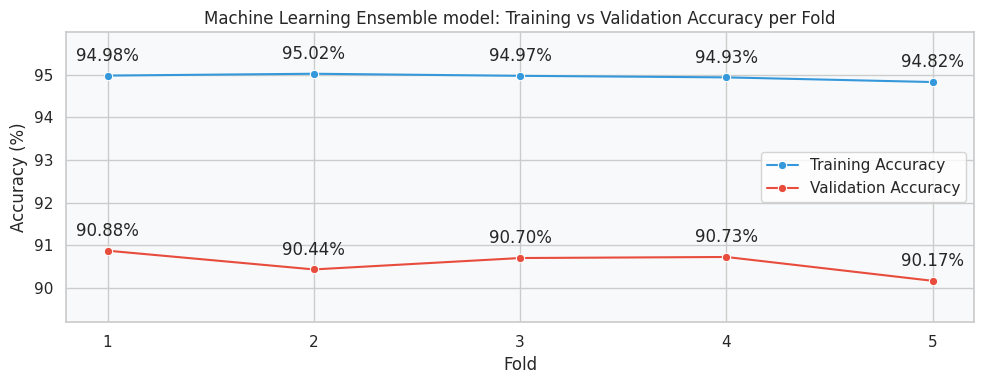

In [144]:
display_each_fold_result("Machine Learning Ensemble", ml_ensemble_each_fold_results)

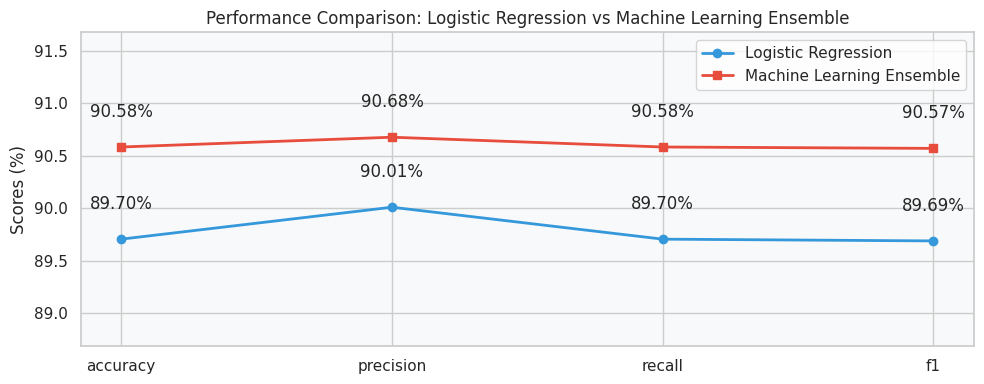

In [145]:
# Compare Model 3: Machine Learning Emsemble model with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=ml_ensemble_results,
                                baseline_name='Logistic Regression', new_model_name='Machine Learning Ensemble')

## Deep Learning Models

#### Optimized Parameters for DL training

In [146]:
# Default parameters
CV = ShuffleSplit(n_splits=2, test_size=0.1, random_state=42) 
EPOCHS = 5
BATCH_SIZE = 32

In [147]:
# Parameters for RandomizedSearchCV
param_dist = {
    'learning_rate': [0.01, 0.001, 0.0001],
    'dense_units': [32, 64, 128],
    'dropout': [0.2, 0.3, 0.4, 0.5],
    'l1_reg': [0.001, 0.01, 0.1],
    'l2_reg': [0.001, 0.01, 0.1],
    'batch_normalization': [True, False],
    
    # options for convolutional layers
    'kernel_initializer': ["he_uniform", 'he_normal'],
    'padding': ['valid', 'same'],  
}

In [148]:
# Split the data into training and validation sets (for deep learning model)
X_train, X_val, y_train, y_val = train_test_split(
    train_sentences_oversampled, 
    train_labels_oversampled, 
    test_size=0.1,  # 10% of the data will be used for validation
    random_state=42
)

#### Optimized Functions for DL training

In [149]:
def filter_param_dist_for_model(model_creation_fn, param_dist=param_dist):
    """
    Filter the parameter distribution dictionary to only include keys that are 
    valid parameters for the given model creation function.

    Parameters:
    - param_dist: Original full parameter distribution dictionary.
    - model_creation_fn: Function used to create the model.

    Returns:
    - Filtered parameter distribution dictionary.
    """
    # Inspect the signature of the model creation function
    valid_params = signature(model_creation_fn).parameters.keys()

    # Filter the param_dist dictionary
    filtered_param_dist = {key: value for key, value in param_dist.items() if key in valid_params}
    
    return filtered_param_dist

In [150]:
def perform_random_search(model_creation_fn, model_name, param_dist=param_dist, X_train=X_train, y_train=y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, n_iter=3, cv=skf):
    """
    Perform Randomized Search for hyperparameter tuning on a deep learning model.
    """
    
    # Define the parameter distribution including epochs and batch_size, 
    param_dist = {
        'epochs': [3, 5],
        'batch_size': [16, 32, 64],
        **(filter_param_dist_for_model(model_creation_fn)) # output is param_dist that have only keys that model_creation_fn has
    }
    
    # Wrap the model creation function with KerasClassifier
    keras_model = KerasClassifier(build_fn=model_creation_fn, epochs=epochs, batch_size=batch_size, verbose=0)

    # Set up RandomizedSearchCV
    randomized_search = RandomizedSearchCV(estimator=keras_model, param_distributions=param_dist, n_iter=n_iter, cv=cv, verbose=0)

    # Fit the RandomizedSearchCV to find the best parameters
    randomized_search.fit(X_train, y_train)

    # Display results
    print(f"\n{model_name} Model Results After Hyperparameter Tuning:\n")
    
    # Get all the results from the randomized search
    cv_results = randomized_search.cv_results_
    for params, mean_test_score, rank in zip(cv_results["params"], cv_results["mean_test_score"], cv_results["rank_test_score"]):
        print(f"Params: {params} - Mean Test Score: {mean_test_score:.2f} - Rank: {rank}")

    # Get the best parameters
    best_parameters = randomized_search.best_params_
    print(f"\nBest Parameters from {model_name} model: {best_parameters}\n")

    # Retrieve the best model after search
    best_model = randomized_search.best_estimator_.model

    return best_model

`RandomizedSearchCV` efficiently explores the hyperparameter space by randomly sampling a subset of parameter combinations and assessing their performance. When used together, they provide a robust and efficient method for hyperparameter tuning, ensuring that the model's performance is well-validated across multiple folds of the dataset.

In [151]:
def display_dl_results(best_model, model_name, X_val=X_val, y_val=y_val):
    """
    Display results of a deep learning model after hyperparameter tuning and evaluate on validation data.
    """
    # Display the best model's summary
    best_model.summary()

    # Predict on the validation set using the best model
    pred_probs = best_model.predict(X_val, verbose=0)
    class_preds = np.argmax(pred_probs, axis=1)

    # Calculate and display results (accuracy, precision, recall, and f1 score)
    results = calculate_results(y_true=y_val, y_pred=class_preds)
    print(f"\n{model_name} Validation Data Results:")
    for metric, score in results.items():
        print(f"- {metric.capitalize()}: {score:.2f}")
        
    return results

### Model 1: Fully Connected Layers Model

***Input (text) -> Tokenize -> Embedding -> Layers -> Output (label probability)***


In [152]:
def create_fc_model(learning_rate=0.001, dense_units=32, dropout=0.5, l2_reg=0.01, activation='relu'):
    inputs = layers.Input(shape=(1, ), dtype="string")
    x = text_vectorizer(inputs)
    x = create_embedding_layer(name='base_dense_embedding')(x)

    # Flatten the embeddings
    x = layers.Flatten()(x)

    # Add fully connected (Dense) layers with dropout
    x = layers.Dense(dense_units*2, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(3, activation="softmax")(x)
    
    model = Model(inputs, outputs, name="fully_connected_layers_model")
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])
    return model

In [153]:
fc_model = perform_random_search(create_fc_model, model_name='Fully Connected Layers')


Fully Connected Layers Model Results After Hyperparameter Tuning:

Params: {'learning_rate': 0.01, 'l2_reg': 0.001, 'epochs': 5, 'dropout': 0.4, 'dense_units': 32, 'batch_size': 16} - Mean Test Score: 0.90 - Rank: 1
Params: {'learning_rate': 0.01, 'l2_reg': 0.01, 'epochs': 5, 'dropout': 0.4, 'dense_units': 64, 'batch_size': 16} - Mean Test Score: 0.88 - Rank: 3
Params: {'learning_rate': 0.0001, 'l2_reg': 0.001, 'epochs': 5, 'dropout': 0.4, 'dense_units': 64, 'batch_size': 64} - Mean Test Score: 0.90 - Rank: 2

Best Parameters from Fully Connected Layers model: {'learning_rate': 0.01, 'l2_reg': 0.001, 'epochs': 5, 'dropout': 0.4, 'dense_units': 32, 'batch_size': 16}



In [154]:
fc_model_results = display_dl_results(fc_model, model_name='Fully Connected Layers')

Model: "fully_connected_layers_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_65 (InputLayer)       [(None, 1)]               0         
                                                                 
 text_vectorization_1 (TextV  (None, 24)               0         
 ectorization)                                                   
                                                                 
 base_dense_embedding (Embed  (None, 24, 128)          2560000   
 ding)                                                           
                                                                 
 flatten_32 (Flatten)        (None, 3072)              0         
                                                                 
 dense_162 (Dense)           (None, 64)                196672    
                                                                 
 dropout_134 (Dropout)       (None, 64

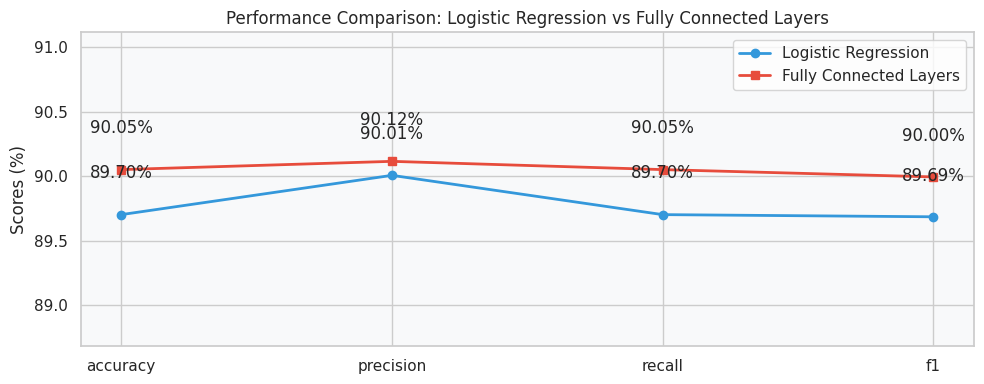

In [155]:
# Compare Model 1: Fully Connected Layer model with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=fc_model_results,
                                baseline_name='Logistic Regression', new_model_name='Fully Connected Layers')

## Dimensionality Reduction and Clustering

In [156]:
def extract_embeddings(model, sentences):
    """
    Uses the provided model to extract embeddings for the given sentences.
    Assumes that the embedding layer is named "embedding_1".
    """
    # Predict using the given model to get the output before the final dense layer
    intermediate_output = model.predict(sentences)

    return intermediate_output

test_embeddings = extract_embeddings(create_fc_model(), test_sentences)

51/51 [==============================] - 0s 2ms/step


In [157]:
len(test_embeddings[test_labels == 2]), len(test_embeddings[test_labels == 1]), len(test_embeddings[test_labels == 0])

(801, 61, 756)

In [158]:
positive_embeddings = test_embeddings[test_labels == 2][:50]
neutral_embeddings = test_embeddings[test_labels == 1][:50]
negative_embeddings = test_embeddings[test_labels == 0][:50]

positive_labels = np.array([2]*50)
neutral_labels = np.array([1]*50)
negative_labels = np.array([0]*50)

sampled_embeddings = np.concatenate([positive_embeddings, neutral_embeddings, negative_embeddings])
sampled_labels = np.concatenate([positive_labels, neutral_labels, negative_labels])

In [159]:
'''
The PCA algorithm expects a 2D array, but sampled_embeddings is a 3D array. 
The shape of sampled_embeddings is (num_samples, sequence_length, embedding_dimension).

To resolve this, average (or max-pool, etc.) over the sequence length to get a 2D shape: (num_samples, embedding_dimension).

(sequence_length = MAX_LENGTH; embedding_dim = output_dim)
'''
sampled_embeddings.shape 

if len(sampled_embeddings.shape) == 3:
    sampled_embeddings = np.mean(sampled_embeddings, axis=1)

In [160]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(sampled_embeddings)

kmeans = KMeans(n_clusters=3, n_init=10)
clustered_labels = kmeans.fit_predict(pca_result)

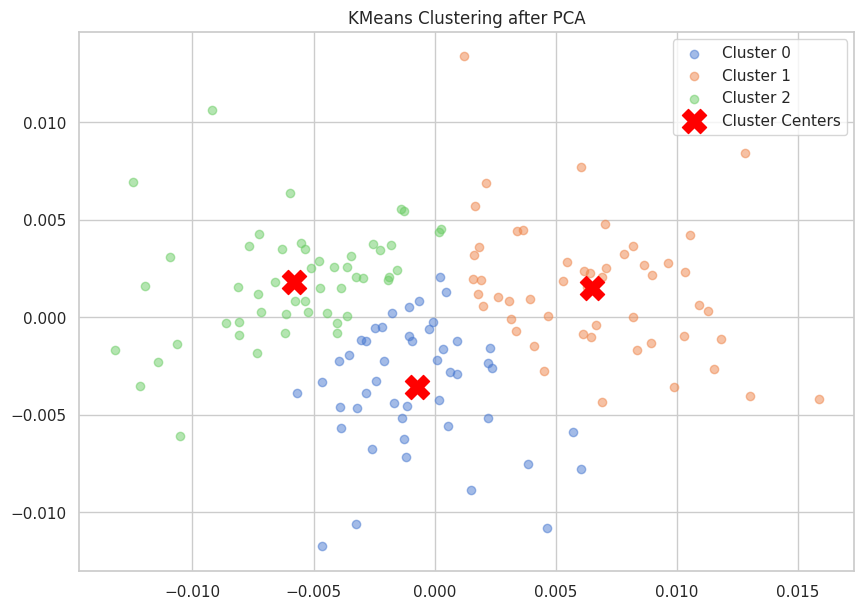

In [161]:
plt.figure(figsize=(10, 7))

for i in range(3): # [0, 1, 2] for [negative, neutral, positive]
    plt.scatter(pca_result[clustered_labels == i][:, 0], 
                pca_result[clustered_labels == i][:, 1], 
                label=f"Cluster {i}", alpha=0.5)
    
# Plotting cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label="Cluster Centers")

plt.legend()
plt.title('KMeans Clustering after PCA')
plt.show()

#### Batch Normalization in the GRU model serves to:

+ `Normalize Activations`: It ensures the outputs from the dense layer have a mean close to 0 and a standard deviation close to 1.

+ `Stabilize Training`: It stabilizes the gradient flow through the network, allowing for a smoother and faster training process.

+ `Allow Higher Learning Rates`: Due to the increased stability, the model can use higher learning rates, which can lead to quicker convergence.

+ `Regularization`: It adds slight noise to the activations, similar to Dropout, helping to prevent overfitting.

### Model 2: GRU

***Input (text) -> Tokenize -> Embedding -> Layers (GRU) -> Output (label probability)***


In [162]:
def create_gru_model(learning_rate=0.01, dense_units=64, dropout=0.5, l2_reg=0.01, activation='relu', kernel_size=2, padding='valid', kernel_initializer="he_uniform", batch_normalization=True):
    inputs = layers.Input(shape=(1,), dtype="string")

    x = text_vectorizer(inputs)
    x = create_embedding_layer(name='gru_embedding')(x)

    x = layers.GRU(dense_units, return_sequences=True, dropout=dropout)(x)
    x = layers.Conv1D(64, kernel_size=kernel_size, padding=padding, kernel_initializer=kernel_initializer)(x)
    x = layers.GlobalAveragePooling1D()(x)  # helps in reducing overfitting
    
    # Regularized dense layer
    x = layers.Dense(dense_units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    if batch_normalization:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)  # Dropout

    outputs = layers.Dense(3, activation="softmax")(x)
    model = Model(inputs, outputs, name="gru_model")
    
    model.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                metrics=["accuracy"])
    
    return model

In [163]:
gru_model = perform_random_search(create_gru_model, model_name='GRU')


GRU Model Results After Hyperparameter Tuning:

Params: {'padding': 'valid', 'learning_rate': 0.01, 'l2_reg': 0.01, 'kernel_initializer': 'he_uniform', 'epochs': 3, 'dropout': 0.5, 'dense_units': 64, 'batch_size': 16, 'batch_normalization': True} - Mean Test Score: 0.90 - Rank: 3
Params: {'padding': 'same', 'learning_rate': 0.001, 'l2_reg': 0.1, 'kernel_initializer': 'he_normal', 'epochs': 3, 'dropout': 0.5, 'dense_units': 32, 'batch_size': 64, 'batch_normalization': False} - Mean Test Score: 0.90 - Rank: 2
Params: {'padding': 'valid', 'learning_rate': 0.001, 'l2_reg': 0.01, 'kernel_initializer': 'he_normal', 'epochs': 3, 'dropout': 0.2, 'dense_units': 128, 'batch_size': 32, 'batch_normalization': False} - Mean Test Score: 0.91 - Rank: 1

Best Parameters from GRU model: {'padding': 'valid', 'learning_rate': 0.001, 'l2_reg': 0.01, 'kernel_initializer': 'he_normal', 'epochs': 3, 'dropout': 0.2, 'dense_units': 128, 'batch_size': 32, 'batch_normalization': False}



In [164]:
gru_model_results = display_dl_results(gru_model, model_name='GRU')

Model: "gru_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_82 (InputLayer)       [(None, 1)]               0         
                                                                 
 text_vectorization_1 (TextV  (None, 24)               0         
 ectorization)                                                   
                                                                 
 gru_embedding (Embedding)   (None, 24, 128)           2560000   
                                                                 
 gru_31 (GRU)                (None, 24, 128)           99072     
                                                                 
 conv1d_31 (Conv1D)          (None, 23, 64)            16448     
                                                                 
 global_average_pooling1d_31  (None, 64)               0         
  (GlobalAveragePooling1D)                               

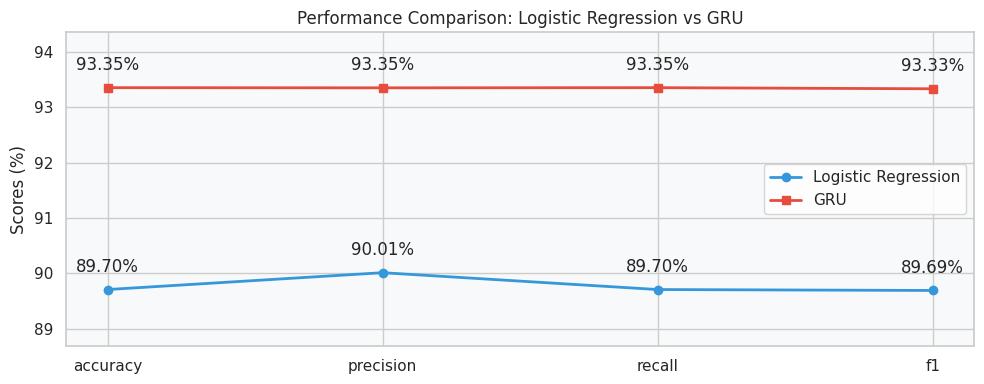

In [165]:
# Compare Model 2: GRU with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=gru_model_results,
                                baseline_name='Logistic Regression', new_model_name='GRU')

### Model 3: Bidirectional LSTM

***Input (text) -> Tokenize -> Embedding -> Bidirectional(Layers) -> Output (label probability)***

In [166]:
def create_bidirectional_lstm_model(learning_rate=0.01, dense_units=64, dropout=0.5, l2_reg=0.01, activation='relu', batch_normalization=True):
    inputs = layers.Input(shape=(1,), dtype="string")

    x = text_vectorizer(inputs)
    x = create_embedding_layer(name='bidirectional_lstm_embedding')(x)

    # Bidirectional LSTM with dropout
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=dropout))(x)
    x = layers.Bidirectional(layers.LSTM(dense_units, dropout=dropout))(x) 

    # Regularized dense layer
    x = layers.Dense(dense_units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x) 
    if batch_normalization:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(3, activation="softmax")(x)
    model = Model(inputs, outputs, name="bidirectional_lstm_model")
    
    model.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                metrics=["accuracy"])
    
    return model

In [167]:
bidirectional_lstm_model = perform_random_search(create_bidirectional_lstm_model, model_name='Bidirectional LSTM')


Bidirectional LSTM Model Results After Hyperparameter Tuning:

Params: {'learning_rate': 0.01, 'l2_reg': 0.001, 'epochs': 5, 'dropout': 0.5, 'dense_units': 64, 'batch_size': 16, 'batch_normalization': False} - Mean Test Score: 0.89 - Rank: 2
Params: {'learning_rate': 0.001, 'l2_reg': 0.01, 'epochs': 5, 'dropout': 0.2, 'dense_units': 128, 'batch_size': 64, 'batch_normalization': True} - Mean Test Score: 0.93 - Rank: 1
Params: {'learning_rate': 0.0001, 'l2_reg': 0.01, 'epochs': 5, 'dropout': 0.3, 'dense_units': 64, 'batch_size': 64, 'batch_normalization': False} - Mean Test Score: 0.89 - Rank: 2

Best Parameters from Bidirectional LSTM model: {'learning_rate': 0.001, 'l2_reg': 0.01, 'epochs': 5, 'dropout': 0.2, 'dense_units': 128, 'batch_size': 64, 'batch_normalization': True}



In [168]:
bidirectional_lstm_model_results = display_dl_results(bidirectional_lstm_model, model_name='Bidirectional LSTM')

Model: "bidirectional_lstm_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_98 (InputLayer)       [(None, 1)]               0         
                                                                 
 text_vectorization_1 (TextV  (None, 24)               0         
 ectorization)                                                   
                                                                 
 bidirectional_lstm_embeddin  (None, 24, 128)          2560000   
 g (Embedding)                                                   
                                                                 
 bidirectional_62 (Bidirecti  (None, 24, 256)          263168    
 onal)                                                           
                                                                 
 bidirectional_63 (Bidirecti  (None, 256)              394240    
 onal)                                    

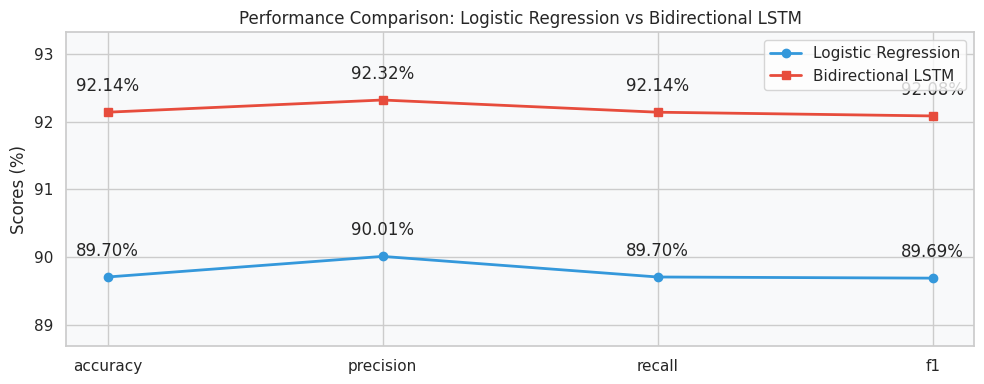

In [169]:
# Compare Model 3: Bidirectional RNN with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=bidirectional_lstm_model_results,
                                baseline_name='Logistic Regression', new_model_name='Bidirectional LSTM')

In [170]:
# Thay vì lưu với đuôi .keras như cũ
# bidirectional_lstm_model.save("bidirectional_lstm_model.keras")

# Chị sửa thành như sau:
model_folder = "bidirectional_lstm_model_saved"

# Lưu dưới định dạng 'tf'
bidirectional_lstm_model.save(model_folder, save_format='tf')

print(f"Đã lưu mô hình thành công vào thư mục: {model_folder}")

Đã lưu mô hình thành công vào thư mục: bidirectional_lstm_model_saved


In [171]:
import shutil

# Đường dẫn của thư mục mô hình hiện tại
model_dir = '/kaggle/working/bidirectional_lstm_model_saved'

# Tên file zip (Kaggle sẽ tạo ra file bidirectional_lstm_model.zip trong thư mục working)
zip_path = '/kaggle/working/bidirectional_lstm_model'

# Nén lại
shutil.make_archive(zip_path, 'zip', model_dir)

print(f"Đã nén xong!")

Đã nén xong!


In [172]:
from tensorflow import keras

# Tải lại mô hình từ thư mục
loaded_model = keras.models.load_model("bidirectional_lstm_model_saved")

# Chạy test thử
# loaded_model.predict(["Câu văn cần phân tích cảm xúc"])

## PhoBert


In [173]:
!pip install transformers

from transformers import TFAutoModel, AutoTokenizer
import tensorflow as tf
from tensorflow.keras import layers, Model
import pandas as pd

# 1. Khởi tạo Tokenizer của PhoBERT
# Lưu ý: Đầu vào nên là văn bản đã được gộp từ (word segment) bằng underthesea
phobert_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
 

import numpy as np

def encode_texts_for_phobert(sentences, max_length=128):
    # Ép kiểu pandas Series hoặc numpy Array về list chuẩn của Python
    if isinstance(sentences, pd.Series):
        sentences = sentences.tolist()
    elif isinstance(sentences, np.ndarray):
        sentences = sentences.tolist()
        
    # Đảm bảo 100% mọi phần tử bên trong đều là chuỗi (string), loại bỏ sạch các object lạ
    sentences = [str(text) for text in sentences]

    encodings = phobert_tokenizer(
        sentences,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='tf' # Trả về tensor của TensorFlow
    )
    return encodings['input_ids'], encodings['attention_mask']

# Khai báo lại độ dài
MAX_LEN = 128 

# Chạy lại mã hóa
train_input_ids, train_attention_mask = encode_texts_for_phobert(X_train, MAX_LEN)
val_input_ids, val_attention_mask = encode_texts_for_phobert(X_val, MAX_LEN)


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [174]:
def create_phobert_model(max_length=128, learning_rate=2e-5):
    # Khai báo 2 cổng đầu vào
    input_ids = layers.Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
    attention_mask = layers.Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')
    
    # Tải mô hình PhoBERT base (thêm from_pt=True nếu Kaggle báo thiếu weights cho TF)
    phobert = TFAutoModel.from_pretrained("vinai/phobert-base")
    
    # Truyền dữ liệu qua PhoBERT
    embeddings = phobert(input_ids, attention_mask=attention_mask)[0]
    
    # Lấy token [CLS] (token đầu tiên của chuỗi) làm vector đại diện cho cả câu
    cls_token = embeddings[:, 0, :]
    
    # Đi qua lớp Dense và Dropout để tinh chỉnh phân loại
    x = layers.Dropout(0.3)(cls_token)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(3, activation='softmax')(x)
    
    model = Model(inputs=[input_ids, attention_mask], outputs=outputs, name="phobert_model")
    
    # Fine-tuning BERT thường dùng learning rate rất nhỏ (2e-5 đến 5e-5)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

phobert_model = create_phobert_model(max_length=MAX_LEN)
phobert_model.summary()

### Huấn luyện mô hình
history_phobert = phobert_model.fit(
    x=[train_input_ids, train_attention_mask],
    y=y_train, # Đã đổi thành y_train chuẩn của em
    validation_data=([val_input_ids, val_attention_mask], y_val), # Đã đổi thành y_val
    epochs=3, 
    batch_size=16 
)

Some layers from the model checkpoint at vinai/phobert-base were not used when initializing TFRobertaModel: ['lm_head']
- This IS expected if you are initializing TFRobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFRobertaModel were initialized from the model checkpoint at vinai/phobert-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaModel for predictions without further training.


Model: "phobert_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 128)]        0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 128)]        0           []                               
                                                                                                  
 tf_roberta_model_1 (TFRobertaM  TFBaseModelOutputWi  134998272  ['input_ids[0][0]',              
 odel)                          thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 128,                                   

In [175]:
import os
import shutil

# 1. Tạo một thư mục tổng để chứa toàn bộ "đồ nghề" mang đi production
production_dir = '/kaggle/working/phobert_production'
model_dir = os.path.join(production_dir, 'keras_model')
tokenizer_dir = os.path.join(production_dir, 'tokenizer')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(tokenizer_dir, exist_ok=True)

# 2. Lưu Mô hình Keras (Tiếp tục dùng save_format='tf' cực kỳ an toàn cho TF/Keras)
phobert_model.save(model_dir, save_format='tf')
print(f"Đã lưu Keras Model vào: {model_dir}")

# 3. Lưu Tokenizer (Giả sử biến tokenizer của chị tên là `tokenizer`)
# Lưu ý: Chị nhớ thay biến `tokenizer` bằng đúng tên biến chị đã khởi tạo từ Hugging Face nhé
tokenizer.save_pretrained(tokenizer_dir)
print(f"Đã lưu Tokenizer vào: {tokenizer_dir}")

# 4. Nén toàn bộ thư mục production lại thành 1 file .zip để tải về
zip_path = '/kaggle/working/phobert_production_bundle'
shutil.make_archive(zip_path, 'zip', production_dir)

print(f"XONG!")

Đã lưu Keras Model vào: /kaggle/working/phobert_production/keras_model
Đã lưu Tokenizer vào: /kaggle/working/phobert_production/tokenizer
XONG!


In [177]:
phobert_model_results = display_dl_results(
    best_model=phobert_model,           # Truyền đúng biến mô hình
    model_name='PhoBert',
    X_val=[val_input_ids, val_attention_mask],  # Dữ liệu đầu vào tập Validation
    y_val=y_val                         # Nhãn của tập Validation
)

Model: "phobert_model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_ids (InputLayer)         [(None, 128)]        0           []                               
                                                                                                  
 attention_mask (InputLayer)    [(None, 128)]        0           []                               
                                                                                                  
 tf_roberta_model_1 (TFRobertaM  TFBaseModelOutputWi  134998272  ['input_ids[0][0]',              
 odel)                          thPoolingAndCrossAt               'attention_mask[0][0]']         
                                tentions(last_hidde                                               
                                n_state=(None, 128,                                   

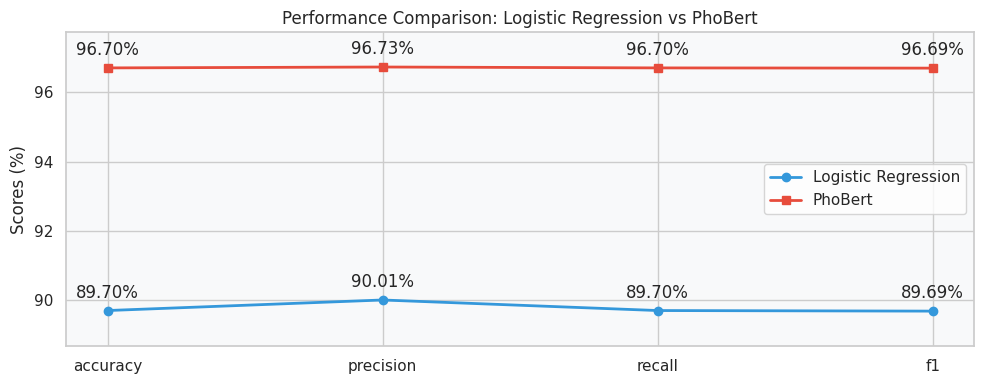

In [178]:
 
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=phobert_model_results,
                                baseline_name='Logistic Regression', new_model_name='PhoBert')

## Compare Models

| Term      | Description | Formula |
|-----------|-------------|---------|
| Accuracy  | Accuracy is the ratio of the correctly predicted instances to the total instances in the dataset. It gives an overall performance measure of the model. | `(True Positives + True Negatives) / (Total Instances)` |
| Precision | Precision (also known as Positive Predictive Value) is the fraction of relevant instances among the retrieved instances. | `True Positives / (True Positives + False Positives)` |
| Recall    | Recall (also known as Sensitivity or True Positive Rate) measures the number of true positive predictions among the actual positive instances in the dataset. | `True Positives / (True Positives + False Negatives)` |
| F1-Score  | The F1-Score is the harmonic mean of precision and recall. | `2 * (Precision * Recall) / (Precision + Recall)` |

In [179]:
all_model_results = pd.DataFrame({'logistic_regression': lr_results,
                                  "svm": svm_results,
                                  'random_forest': rf_results,
                                  'ml_ensemble': ml_ensemble_results,
                                  "fully_connected_layers": fc_model_results,
                                  "gru": gru_model_results,
                                  "bidirectional": bidirectional_lstm_model_results,
                                  "phobert": phobert_model_results
                                 })
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
logistic_regression,89.704386,0.900088,0.897044,0.896876
svm,90.578127,0.907997,0.905781,0.905464
random_forest,93.670220,0.937015,0.936702,0.936199
ml_ensemble,90.582967,0.906762,0.905830,0.905698
fully_connected_layers,90.053372,0.901174,0.900534,0.899967
gru,93.352741,0.933497,0.933527,0.933326
bidirectional,92.139738,0.923201,0.921397,0.920846
phobert,96.700631,0.967263,0.967006,0.966942


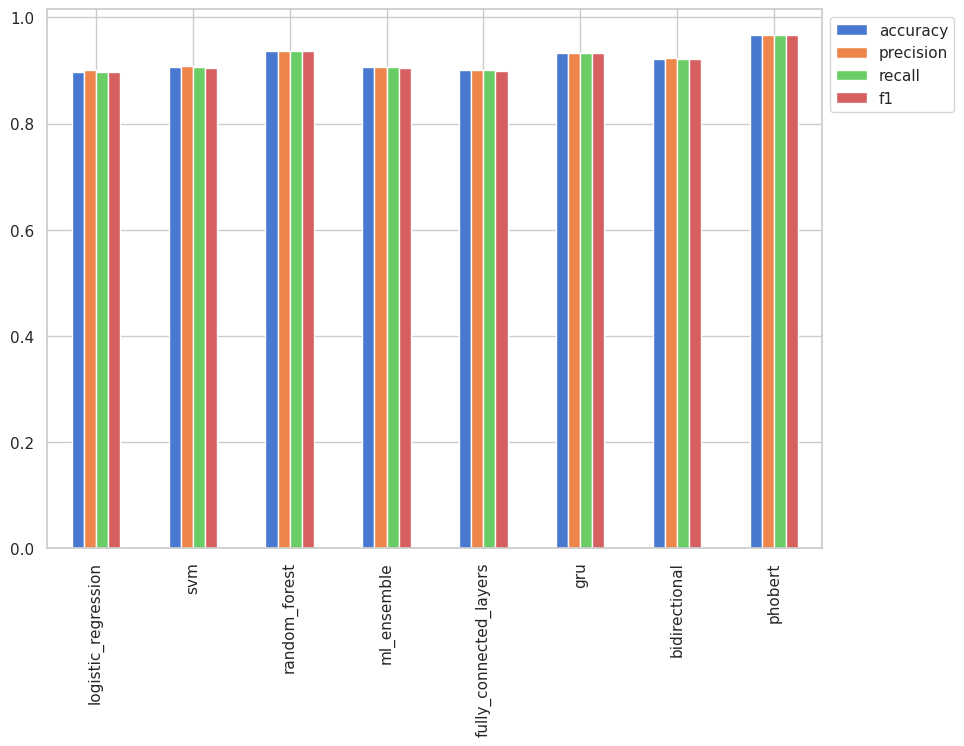

In [180]:
all_model_results["accuracy"] = all_model_results["accuracy"]/100
all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));

## Model Evaluation

In [182]:
# Reverse mapping
reverse_label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Convert sentences to a list if they're in a Pandas Series
if isinstance(test_sentences, pd.Series):
    test_sentences = test_sentences.tolist()

In [183]:
ML_MODELS = {
    'SVM': svm_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'Stacked ML Models': ml_ensemble_model
}

DL_MODELS = {
    "Fully Connected Layers": fc_model,
    "GRU": gru_model,
    "Bidirectional LSTM": bidirectional_lstm_model,
    "PhoBERT": phobert_model
}

# Define which models are deep learning models
is_deep_learning_dict = {
    'SVM': False,
    'Random Forest': False,
    'Logistic Regression': False,
    'Stacked ML Models': False,
    "Fully Connected Layers": True,
    "GRU": True,
    "Bidirectional LSTM": True,
    "PhoBERT": True
}

# Thêm dict mới để nhận diện riêng PhoBERT
is_phobert_dict = {
    'SVM': False, 'Random Forest': False, 'Logistic Regression': False, 'Stacked ML Models': False,
    "Fully Connected Layers": False, "GRU": False, "Bidirectional LSTM": False,
    "PhoBERT": True
}
ALL_MODELS = {**ML_MODELS, **DL_MODELS}

print("Names of all available models:")
for model_type, models_dict in [('Machine Learning', ML_MODELS), ('Deep Learning', DL_MODELS)]:
    print(f"\n{model_type} Models:")
    for model_name in models_dict.keys():
        print(f"- {model_name}")

Names of all available models:

Machine Learning Models:
- SVM
- Random Forest
- Logistic Regression
- Stacked ML Models

Deep Learning Models:
- Fully Connected Layers
- GRU
- Bidirectional LSTM
- PhoBERT


In [201]:
import random
import numpy as np
import tensorflow as tf

def predict_on_multiple_sentences(model_name, sentences=test_sentences, actual_labels=test_labels.tolist(), 
                                  is_deep_learning_dict=is_deep_learning_dict, vectorizer=vectorizer, 
                                  tokenizer=tokenizer, max_length=256, # <-- Đã thêm tham số tokenizer và max_length
                                  label_map=reverse_label_map, ALL_MODELS=ALL_MODELS, n=10):
    
    # Select n random sentences and corresponding labels
    n = min(n, len(sentences)) # ensure that n does not exceed the number of available sentences
    random_indices = random.sample(range(len(sentences)), n)
    random_sentences = [sentences[i] for i in random_indices]
    random_actual_labels = [actual_labels[i] for i in random_indices]

    model = ALL_MODELS[model_name]
    is_deep_learning = is_deep_learning_dict[model_name]
    
    # Print random n sentences
    for i, sentence in enumerate(random_sentences):
        if is_deep_learning:
            # Xử lý riêng biệt nếu mô hình là PhoBERT
            if model_name == 'PhoBERT':
                encoded = tokenizer(
                    sentence,
                    padding='max_length',
                    truncation=True,
                    max_length=max_length,
                    return_tensors='tf'
                )
                pred_probs = model.predict([encoded['input_ids'], encoded['attention_mask']], verbose=0)
            
            # Xử lý cho các mô hình DL khác (đã có sẵn TextVectorization)
            else:
                pred_probs = model.predict([sentence], verbose=0)
                
            pred_labels = tf.argmax(pred_probs, axis=1).numpy()
            pred_prob = np.max(pred_probs, axis=1)[0]  # get the highest probability as the predicted probability

        else:
            test_features = vectorizer.transform([sentence])
            pred_labels = model.predict(test_features)

        # 0, 1, 2 --> negative, neutral, positive
        # Chú ý: Đảm bảo pred_labels[0] trả về đúng kiểu integer để map với label_map
        mapped_pred_label = label_map[int(pred_labels[0]) if not is_deep_learning else pred_labels[0]]
        mapped_actual_label = label_map[random_actual_labels[i]]

        print(f"Text: {sentence}")
        if is_deep_learning:
            print(f"Prediction: {mapped_pred_label}", f"| Probability: {pred_prob * 100:.2f}%", f"| Actual: {mapped_actual_label}\n")
        else:
            print(f"Prediction: {mapped_pred_label}", f"| Actual: {mapped_actual_label}\n")

# Gọi hàm thử nghiệm
# Lưu ý: Chị nhớ đảm bảo biến toàn cục `tokenizer` đã được khai báo trước khi gọi hàm nhé
predict_on_multiple_sentences(model_name='PhoBERT', n=10)

Text: thầy khó quá
Prediction: negative | Probability: 99.38% | Actual: negative

Text: nhiệt_tình luôn cố_gắng giúp_đỡ sinh_viên
Prediction: positive | Probability: 99.96% | Actual: positive

Text: đề_nghị giáo_viên dạy đúng giáo_trình môn_học do nhà_trường đưa ra phần thi giữa kỳ_thầy không dạy heapsort nhưng thi lại ra câu này 4 điểm
Prediction: negative | Probability: 99.59% | Actual: negative

Text: tận tâm_nhiệt_tình giải_đáp thắc_mắc trong quá_trình học
Prediction: positive | Probability: 99.97% | Actual: positive

Text: thầy vui tính dạy rất dễ hiểu và rất nhiệt_tình
Prediction: positive | Probability: 99.96% | Actual: positive

Text: giải_đáp thắc_mắc của sinh_viên nhanh_chóng
Prediction: positive | Probability: 99.87% | Actual: positive

Text: giảng_dạy chi_tiết nhiệt_tình
Prediction: positive | Probability: 99.97% | Actual: positive

Text: hướng_dẫn tốt nhiệt_tình giải_đáp khi sinh_viên có thắc_mắc
Prediction: positive | Probability: 99.97% | Actual: positive

Text: bài giản

In [202]:
# Deep Learning Models only
def check_most_wrong(model, sentences, actual_labels, reverse_label_map, n=10): 
    wrong_predictions = []

    for i, sentence in enumerate(sentences):
        pred_probs = model.predict([sentence], verbose=0)
        pred_label = tf.argmax(pred_probs, axis=1).numpy()
        actual_label_idx = actual_labels[i]

        # Calculate the probability difference between the predicted and actual labels
        prob_diff = abs(pred_probs[0][actual_label_idx] - np.max(pred_probs, axis=1))

        # Map the predicted and actual labels back from integer to string label
        mapped_pred_label = reverse_label_map[pred_label[0]]
        mapped_actual_label = reverse_label_map[actual_label_idx]

        wrong_predictions.append({
            "sentence": sentence,
            "predicted_label": mapped_pred_label,
            "actual_label": mapped_actual_label,
            "probability_diff": prob_diff[0]
        })

    # Sort the predictions by the most wrong
    most_wrong_predictions = sorted(wrong_predictions, key=lambda x: x["probability_diff"], reverse=True)

    # Display the n most wrong predictions
    for prediction in most_wrong_predictions[:n]:
        print(f"\nText: {prediction['sentence']}\n")
        print(f"Prediction: {prediction['predicted_label']}",
              f", Probability Difference: {prediction['probability_diff'] * 100:.2f}%",
              f", Actual: {prediction['actual_label']}\n")

# Usage example
actual_labels = test_labels.tolist() 
actual_test_sentences = test_sentences
check_most_wrong(bidirectional_lstm_model, actual_test_sentences, actual_labels, reverse_label_map, n=10)


Text: tất_cả những gì thấy nói về nhưng tiết thực_hành chỉ là chúng_ta còn các tiết thực_hành và tôi sẽ sắp_xếp để lên_lớp chung thành 1 buổi 5 tiết

Prediction: neutral , Probability Difference: 100.00% , Actual: negative


Text: mở_rộng thêm các kiến_thức bên ngoài

Prediction: neutral , Probability Difference: 100.00% , Actual: positive


Text: cơ mà em học_môn này em hiểu colonlove

Prediction: neutral , Probability Difference: 100.00% , Actual: positive


Text: nắm được các kiến_thức quan_trọng

Prediction: neutral , Probability Difference: 99.99% , Actual: positive


Text: điểm danh đúng giờ

Prediction: neutral , Probability Difference: 99.98% , Actual: positive


Text: phương_pháp thầy dạy giống cấp 3 làm em nhớ hồi cày_cuốc colonsmile

Prediction: neutral , Probability Difference: 99.92% , Actual: negative


Text: và não của con_người không thích sự dễ_dàng nếu chỉ xử_lý sự dễ_dàng thì não khó có_thể phát_triển đến khả_năng của nó

Prediction: negative , Probability Differenc

In [209]:
import tensorflow as tf

def evaluate_model_on_test_data(model, model_name, test_sentences, test_labels, vectorizer, tokenizer=None, max_length=256, is_deep_learning=False):
    '''
    Accept both ML and DL models
    Evaluate selected model on test data
    '''
    if is_deep_learning:
        if model_name == 'PhoBERT':
            # Chuyển đổi toàn bộ test_sentences qua Tokenizer
            # Ép kiểu list(test_sentences) để phòng trường hợp dữ liệu đang ở dạng Pandas Series
            encoded = tokenizer(
                list(test_sentences),
                padding='max_length',
                truncation=True,
                max_length=max_length,
                return_tensors='tf'
            )
            pred_probs = model.predict([encoded['input_ids'], encoded['attention_mask']])
        else:
            # Các mô hình DL truyền thống (LSTM/CNN) đã có lớp TextVectorization
            pred_probs = model.predict(test_sentences)
            
        pred_labels = tf.argmax(pred_probs, axis=1).numpy()
        
    else:
        # Các mô hình ML cơ bản
        test_features = vectorizer.transform(test_sentences) # transform test sentences into numerical feature vectors
        pred_labels = model.predict(test_features)
    
    # Calculate evaluation metrics
    results = calculate_results(test_labels, pred_labels)
    
    return pred_labels, results

In [217]:
def get_models_performance(models_dict, test_sentences, test_labels, vectorizer, tokenizer=None, is_deep_learning_dict=None):
    """
    Duyệt qua danh sách model và tính performance
    """
    performance = {}
    for model_name, model in models_dict.items():
        print(f"Evaluating {model_name}...")
        
        # Kiểm tra xem model hiện tại có phải là Deep Learning không
        is_dl = is_deep_learning_dict[model_name] if is_deep_learning_dict else False
        
        # Gọi hàm đánh giá với ĐẦY ĐỦ tham số đã được gọi rõ tên
        _, results = evaluate_model_on_test_data(
            model=model,
            model_name=model_name,
            test_sentences=test_sentences, 
            test_labels=test_labels,
            vectorizer=vectorizer,
            tokenizer=tokenizer,
            is_deep_learning=is_dl
        )
        
        performance[model_name] = results
    return performance

In [212]:
model_name = "PhoBERT"

# Nhớ đảm bảo biến `tokenizer` đã được load sẵn trong môi trường của chị
pred_labels, test_results_dl = evaluate_model_on_test_data(
    model=ALL_MODELS[model_name],
    model_name=model_name,              # <-- Bổ sung
    test_sentences=test_sentences, 
    test_labels=test_labels, 
    vectorizer=vectorizer, 
    tokenizer=tokenizer,                # <-- Bổ sung
    is_deep_learning=is_deep_learning_dict[model_name]
)

print(test_results_dl)

51/51 [==============================] - 30s 578ms/step
{'accuracy': 94.00494437577255, 'precision': 0.9450635320411207, 'recall': 0.9400494437577256, 'f1': 0.9420852810172456}


In [220]:
# Chạy đánh giá cho các nhóm model (Truyền đủ đồ nghề vào)
ml_models_performance = get_models_performance(
    ML_MODELS, test_sentences, test_labels, 
    vectorizer=vectorizer, 
    is_deep_learning_dict=is_deep_learning_dict
)

dl_models_performance = get_models_performance(
    DL_MODELS, test_sentences, test_labels, 
    vectorizer=vectorizer, 
    tokenizer=tokenizer, # DL thì cần thêm tokenizer cho PhoBERT
    is_deep_learning_dict=is_deep_learning_dict
)

# Tìm model tốt nhất
best_ml_model_name, best_ml_model_score = select_best_model_from_dict(ml_models_performance, metric='accuracy')
best_dl_model_name, best_dl_model_score = select_best_model_from_dict(dl_models_performance, metric='accuracy')

print(f"\n--- KẾT QUẢ ---")
print(f"Best ML Model: {best_ml_model_name} ({best_ml_model_score:.2f}%)")
print(f"Best DL Model: {best_dl_model_name} ({best_dl_model_score:.2f}%)")

Evaluating SVM...
Evaluating Random Forest...
Evaluating Logistic Regression...
Evaluating Stacked ML Models...
Evaluating Fully Connected Layers...
51/51 [==============================] - 0s 2ms/step
Evaluating GRU...
51/51 [==============================] - 0s 2ms/step
Evaluating Bidirectional LSTM...
51/51 [==============================] - 0s 5ms/step
Evaluating PhoBERT...
51/51 [==============================] - 29s 561ms/step

--- KẾT QUẢ ---
Best ML Model: Random Forest (88.38%)
Best DL Model: PhoBERT (94.00%)
